# Chapter 13 Python Lab  
## Double Integrals and Riemann Sums

This lab accompanies **Chapter 13: Double Integrals and Riemann Sums**.

The central idea is that a double integral adds up values of a function over a two-dimensional region:

$$
\iint_R f(x,y)\,dA.
$$

When $f(x,y)\ge 0$, this can represent volume under the surface $z=f(x,y)$ above the region $R$.  
More generally, double integrals compute signed volume, area, mass, average value, probability, and accumulated quantities over a region.

This lab uses Python to explore:

- Riemann sums over rectangles;
- midpoint approximations;
- convergence of numerical double integrals;
- Fubini's theorem and iterated integrals;
- double integrals over nonrectangular regions;
- changing the order of integration;
- area and average value;
- mass and center of mass;
- Monte Carlo integration;
- and double integrals as expectations in probability.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. approximate double integrals by Riemann sums;
2. visualize partitions and sample points;
3. interpret $\iint_R f(x,y)\,dA$ as accumulated signed volume;
4. compute iterated integrals numerically in either order;
5. integrate over Type I and Type II regions;
6. approximate area by integrating the constant function $1$;
7. compute average value of a function over a region;
8. compute mass and center of mass from a density function;
9. estimate double integrals by Monte Carlo sampling;
10. connect double integrals with probability and data applications.

## Source note

This notebook was generated from the uploaded Chapter 13 QMD file.  
The extracted early headings from the source file include:

- Learning objectives
- 13.1 From one-dimensional area to two-dimensional accumulation
- The main shift
- 13.2 Rectangular regions and partitions
- 13.3 The double integral on a rectangle
- Definition: double integral over a rectangle
- Volume interpretation
- 13.4 Worked example: upper-right Riemann sum
- 13.5 The midpoint rule for double integrals
- Worked example: midpoint rule for $x^2y$
- Why midpoint sampling is often good
- 13.6 Fubini's theorem on rectangles

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=6, suppress=True)

def make_grid(xmin, xmax, ymin, ymax, n=250):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Z = f(X, Y)
    return np.asarray(Z, dtype=float)

def make_3d_axes(title=None, elev=28, azim=45):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title:
        ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    return fig, ax

def plot_surface_over_rectangle(f, xmin, xmax, ymin, ymax, n=120,
                                title="Surface over rectangle", elev=30, azim=45):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=n)
    Z = safe_eval_2d(f, X, Y)
    fig, ax = make_3d_axes(title=title, elev=elev, azim=azim)
    ax.plot_surface(X, Y, Z, linewidth=0, alpha=0.85)
    plt.show()
    return X, Y, Z

def plot_contours(f, xmin, xmax, ymin, ymax, n=300, levels=15,
                  title="Contour plot", equal=True):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=n)
    Z = safe_eval_2d(f, X, Y)
    fig, ax = plt.subplots(figsize=(7, 6))
    cs = ax.contour(X, Y, Z, levels=levels)
    ax.clabel(cs, inline=True, fontsize=8)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    if equal:
        ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    plt.show()
    return X, Y, Z

def midpoint_riemann_rectangle(f, xmin, xmax, ymin, ymax, nx, ny):
    dx = (xmax - xmin)/nx
    dy = (ymax - ymin)/ny
    x_mid = xmin + (np.arange(nx) + 0.5)*dx
    y_mid = ymin + (np.arange(ny) + 0.5)*dy
    Xmid, Ymid = np.meshgrid(x_mid, y_mid)
    Zmid = safe_eval_2d(f, Xmid, Ymid)
    return float(np.sum(Zmid)*dx*dy), Xmid, Ymid, Zmid, dx, dy

def trapezoid_rectangle(f, xmin, xmax, ymin, ymax, nx=400, ny=400):
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    X, Y = np.meshgrid(x, y)
    Z = safe_eval_2d(f, X, Y)
    inner = np.trapezoid(Z, x, axis=1)
    return float(np.trapezoid(inner, y))

def midpoint_region(f, xmin, xmax, ymin, ymax, mask, nx, ny):
    dx = (xmax - xmin)/nx
    dy = (ymax - ymin)/ny
    x_mid = xmin + (np.arange(nx) + 0.5)*dx
    y_mid = ymin + (np.arange(ny) + 0.5)*dy
    Xmid, Ymid = np.meshgrid(x_mid, y_mid)
    inside = mask(Xmid, Ymid)
    Zmid = safe_eval_2d(f, Xmid, Ymid)
    return float(np.sum(Zmid[inside])*dx*dy), Xmid, Ymid, Zmid, inside, dx, dy

def monte_carlo_integral(f, xmin, xmax, ymin, ymax, mask=None, n=100_000, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(xmin, xmax, n)
    Y = rng.uniform(ymin, ymax, n)
    box_area = (xmax - xmin)*(ymax - ymin)
    if mask is None:
        values = safe_eval_2d(f, X, Y)
        estimate = box_area*np.mean(values)
        standard_error = box_area*np.std(values, ddof=1)/np.sqrt(n)
        return estimate, standard_error, X, Y, np.ones_like(X, dtype=bool), values
    inside = mask(X, Y)
    values = np.zeros(n)
    values[inside] = safe_eval_2d(f, X[inside], Y[inside])
    estimate = box_area*np.mean(values)
    standard_error = box_area*np.std(values, ddof=1)/np.sqrt(n)
    return estimate, standard_error, X, Y, inside, values

def polygonal_area_from_mask(mask, xmin, xmax, ymin, ymax, nx=500, ny=500):
    val, *_ = midpoint_region(lambda X, Y: np.ones_like(X), xmin, xmax, ymin, ymax, mask, nx, ny)
    return val

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-dytcusx9 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Riemann sums over rectangles

For a rectangle

$$
R=[a,b]\times[c,d],
$$

partition the rectangle into small subrectangles.  
A Riemann sum has the form

$$
\sum_{i=1}^{m}\sum_{j=1}^{n} f(x_{ij}^*,y_{ij}^*)\,\Delta A,
$$

where

$$
\Delta A=\Delta x\,\Delta y.
$$

As the subrectangles become smaller, the sum approaches the double integral

$$
\iint_R f(x,y)\,dA.
$$

## 1. A simple rectangle example

Let

$$
f(x,y)=x+2y
$$

over

$$
R=[0,2]\times[1,3].
$$

The exact integral is

$$
\int_0^2\int_1^3 (x+2y)\,dy\,dx.
$$

In [2]:
def f_linear(X, Y):
    return X + 2*Y

xmin, xmax = 0, 2
ymin, ymax = 1, 3

approx, Xmid, Ymid, Zmid, dx, dy = midpoint_riemann_rectangle(
    f_linear, xmin, xmax, ymin, ymax, nx=4, ny=4
)

exact = 12.0

print("Midpoint Riemann sum with 4 by 4 grid:", approx)
print("Exact value:", exact)
print("Error:", approx - exact)
print("dx, dy, dA:", dx, dy, dx*dy)

Midpoint Riemann sum with 4 by 4 grid: 20.0
Exact value: 12.0
Error: 8.0
dx, dy, dA: 0.5 0.5 0.25


## 2. Visualize the partition and midpoint sample points

Each sample point contributes

$$
f(x_{ij}^*,y_{ij}^*)\Delta A
$$

to the Riemann sum.

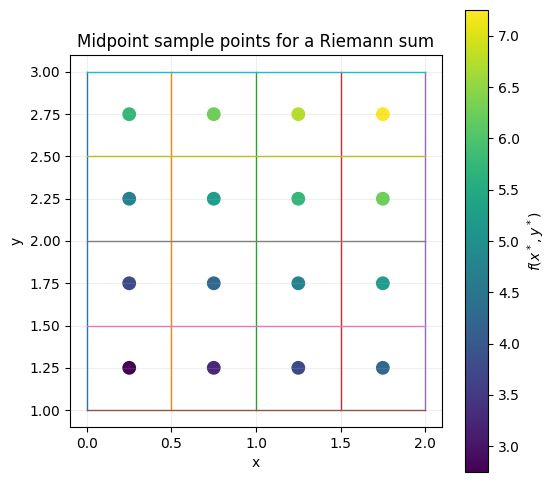

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))

# Draw rectangle grid
nx, ny = 4, 4
x_edges = np.linspace(xmin, xmax, nx+1)
y_edges = np.linspace(ymin, ymax, ny+1)

for x in x_edges:
    ax.plot([x, x], [ymin, ymax], linewidth=1)
for y in y_edges:
    ax.plot([xmin, xmax], [y, y], linewidth=1)

sc = ax.scatter(Xmid.ravel(), Ymid.ravel(), c=Zmid.ravel(), s=80)
fig.colorbar(sc, ax=ax, label=r"$f(x^*,y^*)$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Midpoint sample points for a Riemann sum")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.2)
plt.show()

## 3. Surface interpretation

If $f(x,y)\ge 0$, the double integral is volume under the surface above the rectangle.

Here $f(x,y)=x+2y$ is positive on the rectangle.

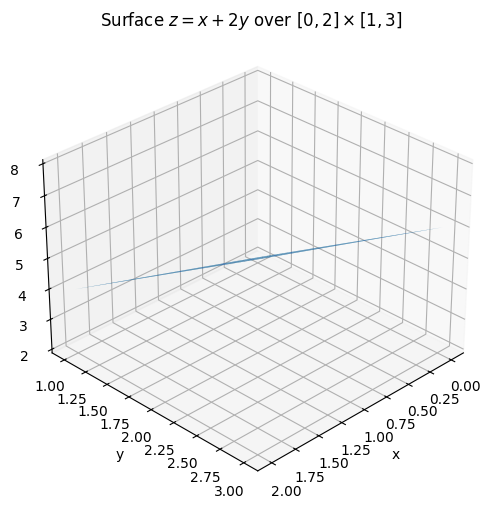

(array([[0.      , 0.025316, 0.050633, ..., 1.949367, 1.974684, 2.      ],
        [0.      , 0.025316, 0.050633, ..., 1.949367, 1.974684, 2.      ],
        [0.      , 0.025316, 0.050633, ..., 1.949367, 1.974684, 2.      ],
        ...,
        [0.      , 0.025316, 0.050633, ..., 1.949367, 1.974684, 2.      ],
        [0.      , 0.025316, 0.050633, ..., 1.949367, 1.974684, 2.      ],
        [0.      , 0.025316, 0.050633, ..., 1.949367, 1.974684, 2.      ]],
       shape=(80, 80)),
 array([[1.      , 1.      , 1.      , ..., 1.      , 1.      , 1.      ],
        [1.025316, 1.025316, 1.025316, ..., 1.025316, 1.025316, 1.025316],
        [1.050633, 1.050633, 1.050633, ..., 1.050633, 1.050633, 1.050633],
        ...,
        [2.949367, 2.949367, 2.949367, ..., 2.949367, 2.949367, 2.949367],
        [2.974684, 2.974684, 2.974684, ..., 2.974684, 2.974684, 2.974684],
        [3.      , 3.      , 3.      , ..., 3.      , 3.      , 3.      ]],
       shape=(80, 80)),
 array([[2.      , 2.025

In [4]:
plot_surface_over_rectangle(
    f_linear,
    xmin, xmax, ymin, ymax,
    n=80,
    title=r"Surface $z=x+2y$ over $[0,2]\times[1,3]$"
)

## 4. Convergence of midpoint sums

As the number of subrectangles increases, the midpoint Riemann sum approaches the exact double integral.

In [5]:
sizes = [2, 4, 8, 16, 32, 64, 128]
rows = []

for n in sizes:
    approx, *_ = midpoint_riemann_rectangle(f_linear, xmin, xmax, ymin, ymax, nx=n, ny=n)
    rows.append((n, approx, approx - exact))

print(f"{'n by n':>8s} {'midpoint sum':>16s} {'error':>16s}")
for n, approx, err in rows:
    print(f"{n:8d} {approx:16.10f} {err:16.10f}")

  n by n     midpoint sum            error
       2    20.0000000000     8.0000000000
       4    20.0000000000     8.0000000000
       8    20.0000000000     8.0000000000
      16    20.0000000000     8.0000000000
      32    20.0000000000     8.0000000000
      64    20.0000000000     8.0000000000
     128    20.0000000000     8.0000000000


For this linear function, the midpoint rule is exact on each subrectangle, so the total error is essentially zero up to floating-point roundoff.

## 5. A nonlinear example

Now use

$$
f(x,y)=e^{-x^2-y^2}
$$

on

$$
[-1,1]\times[-1,1].
$$

There is no elementary antiderivative for the one-variable Gaussian, so numerical approximation is natural.

In [6]:
def f_gaussian(X, Y):
    return np.exp(-X**2 - Y**2)

xmin, xmax = -1, 1
ymin, ymax = -1, 1

reference = trapezoid_rectangle(f_gaussian, xmin, xmax, ymin, ymax, nx=900, ny=900)
print("High-resolution reference value:", reference)

sizes = [4, 8, 16, 32, 64, 128]
print(f"{'n by n':>8s} {'midpoint sum':>16s} {'error vs ref':>16s}")

for n in sizes:
    approx, *_ = midpoint_riemann_rectangle(f_gaussian, xmin, xmax, ymin, ymax, nx=n, ny=n)
    print(f"{n:8d} {approx:16.10f} {approx-reference:16.10f}")

High-resolution reference value: 2.2309833283816536
  n by n     midpoint sum     error vs ref
       4     2.2776722270     0.0466888986
       8     2.2424890701     0.0115057417
      16     2.2338505551     0.0028672268
      32     2.2317008338     0.0007175054
      64     2.2311640232     0.0001806948
     128     2.2310298593     0.0000465309


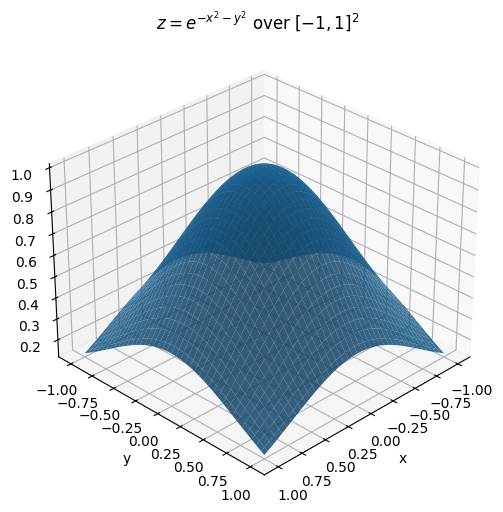

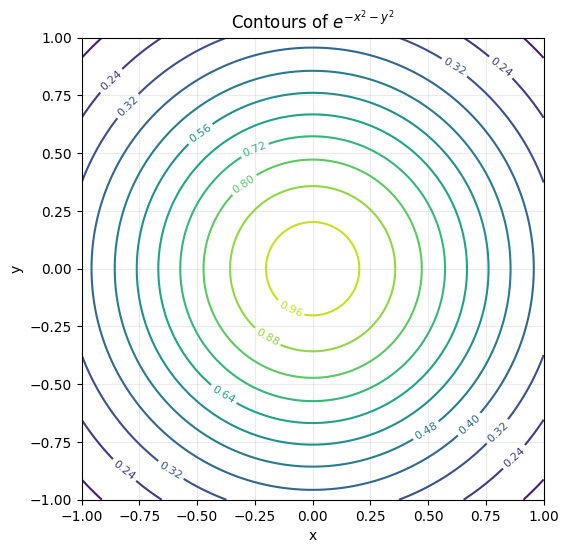

(array([[-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        ...,
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ]], shape=(300, 300)),
 array([[-1.      , -1.      , -1.      , ..., -1.      , -1.      ,
         -1.      ],
        [-0.993311, -0.993311, -0.993311, ..., -0.993311, -0.993311,
         -0.993311],
        [-0.986622, -0.986622, -0.986622, ..., -0.986622, -0.986622,
         -0.986622],
        ...,
        [ 0.986622,  0.986622,  0.986622, ...,  0.986622,  0.986622,
          0.986622],
        [ 0.993311,  0.993311,  0.993311, ...,  0.9933

In [7]:
plot_surface_over_rectangle(
    f_gaussian,
    -1, 1, -1, 1,
    n=120,
    title=r"$z=e^{-x^2-y^2}$ over $[-1,1]^2$"
)

plot_contours(
    f_gaussian,
    -1, 1, -1, 1,
    levels=12,
    title=r"Contours of $e^{-x^2-y^2}$"
)

---

# Part II. Fubini's theorem and iterated integrals

For a continuous function on a rectangle,

$$
\iint_R f(x,y)\,dA
=
\int_a^b\int_c^d f(x,y)\,dy\,dx
=
\int_c^d\int_a^b f(x,y)\,dx\,dy.
$$

This is **Fubini's theorem**.  
It allows us to compute double integrals as repeated one-variable integrals.

## 6. Numerical iterated integrals in either order

Let

$$
f(x,y)=x^2+y
$$

over

$$
R=[0,2]\times[0,3].
$$

In [8]:
def f_fubini(X, Y):
    return X**2 + Y

xmin, xmax = 0, 2
ymin, ymax = 0, 3

# Exact value:
# integral_0^2 integral_0^3 (x^2+y) dy dx
# inner: 3x^2 + 9/2; outer: 3*(8/3)+9 = 17
exact = 17.0

# y then x
x = np.linspace(xmin, xmax, 600)
y = np.linspace(ymin, ymax, 700)
X, Y = np.meshgrid(x, y)
Z = f_fubini(X, Y)

inner_y = np.trapezoid(Z, y, axis=0)
integral_y_then_x = np.trapezoid(inner_y, x)

inner_x = np.trapezoid(Z, x, axis=1)
integral_x_then_y = np.trapezoid(inner_x, y)

print("Integral dy then dx:", integral_y_then_x)
print("Integral dx then dy:", integral_x_then_y)
print("Exact value:", exact)
print("Difference between orders:", integral_y_then_x - integral_x_then_y)

Integral dy then dx: 17.000011148240947
Integral dx then dy: 17.000011148240944
Exact value: 17.0
Difference between orders: 3.552713678800501e-15


## 7. Visualize slices used in iterated integration

Integrating with respect to $y$ first means accumulating vertical slices for each fixed $x$.  
Integrating with respect to $x$ first means accumulating horizontal slices for each fixed $y$.

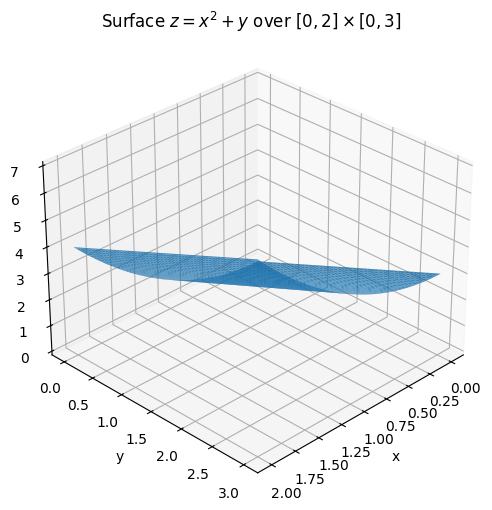

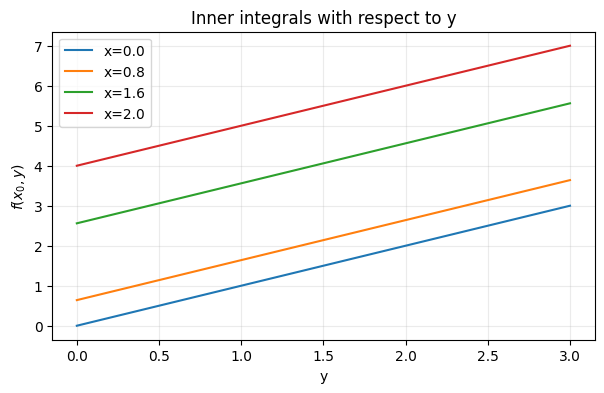

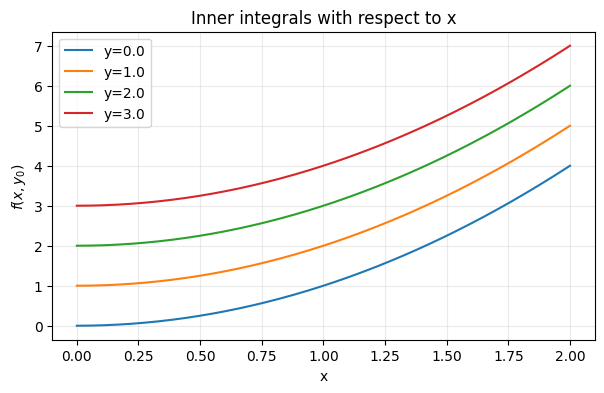

In [9]:
plot_surface_over_rectangle(
    f_fubini,
    xmin, xmax, ymin, ymax,
    n=100,
    title=r"Surface $z=x^2+y$ over $[0,2]\times[0,3]$"
)

# Slices
x_values = [0.0, 0.8, 1.6, 2.0]
y_line = np.linspace(ymin, ymax, 400)

plt.figure(figsize=(7, 4))
for x0 in x_values:
    plt.plot(y_line, f_fubini(x0, y_line), label=f"x={x0}")
plt.xlabel("y")
plt.ylabel(r"$f(x_0,y)$")
plt.title("Inner integrals with respect to y")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

y_values = [0.0, 1.0, 2.0, 3.0]
x_line = np.linspace(xmin, xmax, 400)

plt.figure(figsize=(7, 4))
for y0 in y_values:
    plt.plot(x_line, f_fubini(x_line, y0), label=f"y={y0}")
plt.xlabel("x")
plt.ylabel(r"$f(x,y_0)$")
plt.title("Inner integrals with respect to x")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part III. Area and average value

The area of a region $R$ is

$$
\text{Area}(R)=\iint_R 1\,dA.
$$

The average value of $f$ over $R$ is

$$
f_{\text{avg}}=\frac{1}{\text{Area}(R)}\iint_R f(x,y)\,dA.
$$

## 8. Area of a disk by Riemann sum

For the disk

$$
R=\{(x,y):x^2+y^2\le 1\},
$$

the exact area is $\pi$.

In [10]:
def disk_mask(X, Y):
    return X**2 + Y**2 <= 1

def one_function(X, Y):
    return np.ones_like(X, dtype=float)

for n in [40, 80, 160, 320, 640]:
    area_est, *_ = midpoint_region(one_function, -1, 1, -1, 1, disk_mask, nx=n, ny=n)
    print(f"n={n:4d}, area estimate={area_est:.8f}, error={area_est-np.pi:.8f}")

n=  40, area estimate=3.16000000, error=0.01840735
n=  80, area estimate=3.14000000, error=-0.00159265
n= 160, area estimate=3.14187500, error=0.00028235
n= 320, area estimate=3.14265625, error=0.00106360
n= 640, area estimate=3.14156250, error=-0.00003015


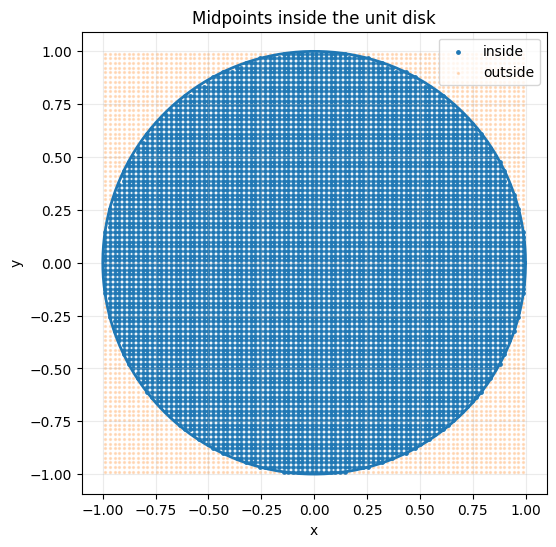

In [11]:
area_est, Xmid, Ymid, Zmid, inside, dx, dy = midpoint_region(
    one_function, -1, 1, -1, 1, disk_mask, nx=90, ny=90
)

plt.figure(figsize=(6, 6))
plt.scatter(Xmid[inside], Ymid[inside], s=6, label="inside")
plt.scatter(Xmid[~inside], Ymid[~inside], s=2, alpha=0.2, label="outside")
theta = np.linspace(0, 2*np.pi, 500)
plt.plot(np.cos(theta), np.sin(theta), linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Midpoints inside the unit disk")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 9. Average value over a disk

Compute the average value of

$$
f(x,y)=x^2+y^2
$$

over the unit disk.

The exact answer is

$$
\frac{1}{\pi}\int_0^{2\pi}\int_0^1 r^2\,r\,dr\,d\theta
=
\frac{1}{2}.
$$

In [12]:
def r_squared(X, Y):
    return X**2 + Y**2

integral_est, *_ = midpoint_region(r_squared, -1, 1, -1, 1, disk_mask, nx=600, ny=600)
area_est, *_ = midpoint_region(one_function, -1, 1, -1, 1, disk_mask, nx=600, ny=600)

avg_est = integral_est/area_est

print("Integral estimate:", integral_est)
print("Area estimate:", area_est)
print("Average value estimate:", avg_est)
print("Exact average value:", 0.5)

Integral estimate: 1.5713368814814819
Area estimate: 3.1421333333333337
Average value estimate: 0.5000859972465039
Exact average value: 0.5


---

# Part IV. Nonrectangular regions: Type I regions

A Type I region has the form

$$
R=\{(x,y):a\le x\le b,\;g_1(x)\le y\le g_2(x)\}.
$$

Then

$$
\iint_R f(x,y)\,dA
=
\int_a^b\int_{g_1(x)}^{g_2(x)}f(x,y)\,dy\,dx.
$$

## 10. Region under a parabola

Let

$$
R=\{(x,y):0\le x\le1,\;0\le y\le x^2\}.
$$

Compute

$$
\iint_R (x+y)\,dA.
$$

In [13]:
def f_type1(X, Y):
    return X + Y

def mask_type1(X, Y):
    return (0 <= X) & (X <= 1) & (0 <= Y) & (Y <= X**2)

# Midpoint region approximation in bounding box.
for n in [60, 120, 240, 480]:
    val, *_ = midpoint_region(f_type1, 0, 1, 0, 1, mask_type1, nx=n, ny=n)
    print(f"n={n:4d}, integral estimate={val:.10f}")

# Exact by hand:
# integral_0^1 integral_0^{x^2} (x+y) dy dx
# inner = x*x^2 + (x^2)^2/2 = x^3 + x^4/2
# outer = 1/4 + 1/10 = 7/20
exact = 7/20
print("Exact value:", exact)

n=  60, integral estimate=0.3512870370
n= 120, integral estimate=0.3503009259
n= 240, integral estimate=0.3500732060
n= 480, integral estimate=0.3500177771
Exact value: 0.35


ValueError: 
0\le y\le x^2
 ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 1), (line:1, col:2)

<Figure size 600x600 with 1 Axes>

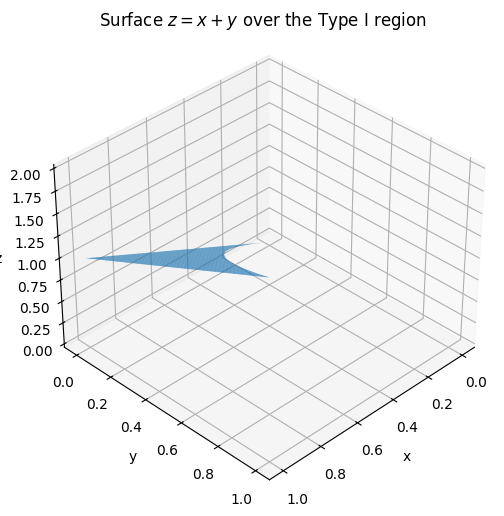

In [14]:
x, y, X, Y = make_grid(0, 1, 0, 1, n=350)
Z = f_type1(X, Y)
inside = mask_type1(X, Y)

plt.figure(figsize=(6, 6))
plt.contourf(X, Y, inside.astype(float), levels=[-0.5, 0.5, 1.5], alpha=0.45)
x_curve = np.linspace(0, 1, 400)
plt.plot(x_curve, x_curve**2, linewidth=3, label=r"$y=x^2$")
plt.plot([0,1], [0,0], linewidth=3)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Type I region: $0\le y\le x^2$")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

fig, ax = make_3d_axes(title=r"Surface $z=x+y$ over the Type I region", elev=35, azim=45)
Zmasked = np.where(inside, Z, np.nan)
ax.plot_surface(X, Y, Zmasked, linewidth=0, alpha=0.85)
plt.show()

## 11. Numerical iterated integral over a Type I region

We can approximate

$$
\int_a^b\int_{g_1(x)}^{g_2(x)} f(x,y)\,dy\,dx
$$

by performing a one-dimensional quadrature in $y$ for many $x$ values.

Iterated integral estimate: 0.35000116127496916
Exact value: 0.35


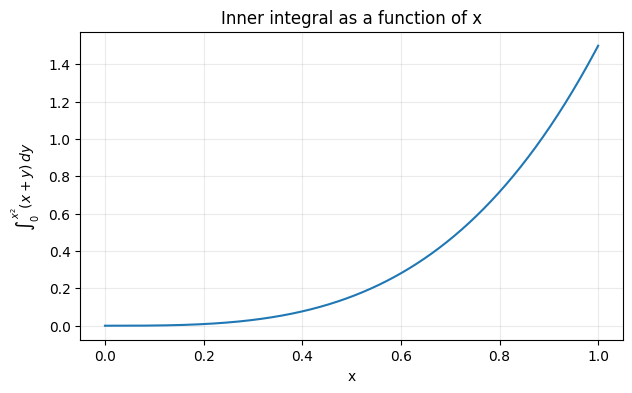

In [15]:
def iterated_type1(f, a, b, g1, g2, nx=500, ny=400):
    xs = np.linspace(a, b, nx)
    inner_values = []
    for x0 in xs:
        ys = np.linspace(g1(x0), g2(x0), ny)
        vals = f(x0, ys)
        inner_values.append(np.trapezoid(vals, ys))
    return float(np.trapezoid(inner_values, xs)), xs, np.array(inner_values)

val_type1, xs, inner_values = iterated_type1(
    f_type1,
    0, 1,
    lambda x: 0*x,
    lambda x: x**2,
    nx=600,
    ny=400
)

print("Iterated integral estimate:", val_type1)
print("Exact value:", exact)

plt.figure(figsize=(7, 4))
plt.plot(xs, inner_values)
plt.xlabel("x")
plt.ylabel(r"$\int_0^{x^2}(x+y)\,dy$")
plt.title("Inner integral as a function of x")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part V. Changing the order of integration

Changing the order can simplify an integral.

For the region

$$
R=\{(x,y):0\le x\le1,\;0\le y\le x^2\},
$$

the same region can be written as

$$
0\le y\le1,\qquad \sqrt y\le x\le1.
$$

So

$$
\int_0^1\int_0^{x^2} f(x,y)\,dy\,dx
=
\int_0^1\int_{\sqrt y}^{1} f(x,y)\,dx\,dy.
$$

## 12. Verify both orders numerically

In [16]:
def iterated_type2(f, c, d, h1, h2, ny=500, nx=400):
    ys = np.linspace(c, d, ny)
    inner_values = []
    for y0 in ys:
        xs = np.linspace(h1(y0), h2(y0), nx)
        vals = f(xs, y0)
        inner_values.append(np.trapezoid(vals, xs))
    return float(np.trapezoid(inner_values, ys)), ys, np.array(inner_values)

val_type2, ys, inner_x_values = iterated_type2(
    f_type1,
    0, 1,
    lambda y: np.sqrt(y),
    lambda y: 1 + 0*y,
    ny=600,
    nx=400
)

print("Type I order value:", val_type1)
print("Type II order value:", val_type2)
print("Exact value:", exact)
print("Difference:", val_type1 - val_type2)

Type I order value: 0.35000116127496916
Type II order value: 0.3499996545196241
Exact value: 0.35
Difference: 1.506755345048738e-06


In [17]:
plt.figure(figsize=(7, 4))
plt.plot(ys, inner_x_values)
plt.xlabel("y")
plt.ylabel(r"$\int_{\sqrt y}^{1}(x+y)\,dx$")
plt.title("Inner integral after changing order")
plt.grid(True, alpha=0.25)
plt.show()

ValueError: 
\int_{\sqrt y}^{1}(x+y)\,dx
            ^
ParseSyntaxException: Expected \sqrt{value}, found 'y'  (at char 12), (line:1, col:13)

<Figure size 700x400 with 1 Axes>

### Guided task 2

Consider

$$
R=\{(x,y):0\le y\le x,\;0\le x\le1\}.
$$

Compute

$$
\iint_R e^{x^2}\,dA.
$$

The order $dy\,dx$ gives

$$
\int_0^1\int_0^x e^{x^2}\,dy\,dx
=
\int_0^1 x e^{x^2}\,dx,
$$

which is easy.  
Changing order gives

$$
\int_0^1\int_y^1 e^{x^2}\,dx\,dy.
$$

In [18]:
def f_exp_x2(X, Y):
    return np.exp(X**2)

# Easy order:
x = np.linspace(0, 1, 2000)
easy_integrand = x*np.exp(x**2)
easy_value = np.trapezoid(easy_integrand, x)

# Exact:
exact_value = 0.5*(np.e - 1)

# Changed order:
changed_value, *_ = iterated_type2(
    f_exp_x2,
    0, 1,
    lambda y: y,
    lambda y: 1 + 0*y,
    ny=700,
    nx=700
)

print("Easy order numerical value:", easy_value)
print("Changed order numerical value:", changed_value)
print("Exact value:", exact_value)

Easy order numerical value:

 0.8591410634379663
Changed order numerical value: 0.85914089493749
Exact value: 0.8591409142295225


---

# Part VI. Monte Carlo integration

Monte Carlo integration estimates an integral using random samples.

For a rectangle $B$ containing $R$,

$$
\iint_R f(x,y)\,dA
=
\text{Area}(B)\cdot
\mathbb E\left[f(X,Y)\mathbf 1_R(X,Y)\right],
$$

where $(X,Y)$ is uniformly distributed over $B$.

## 13. Monte Carlo estimate of disk area

Estimate

$$
\iint_{x^2+y^2\le1}1\,dA=\pi.
$$

In [19]:
sample_sizes = [1_000, 5_000, 20_000, 100_000, 300_000]

print(f"{'n':>10s} {'estimate':>14s} {'std error':>14s} {'error':>14s}")
for n in sample_sizes:
    est, se, Xs, Ys, inside, vals = monte_carlo_integral(
        one_function, -1, 1, -1, 1, mask=disk_mask, n=n, seed=13
    )
    print(f"{n:10d} {est:14.8f} {se:14.8f} {est-np.pi:14.8f}")

         n       estimate      std error          error
      1000     3.18400000     0.05099750     0.04240735
      5000     3.15600000     0.02308331     0.01440735
     20000     3.12960000     0.01167078    -0.01199265
    100000     3.13804000     0.00520086    -0.00355265
    300000     3.13680000     0.00300427    -0.00479265


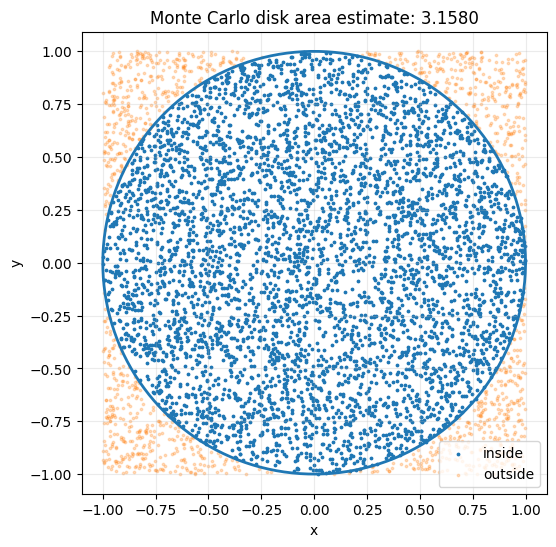

In [20]:
est, se, Xs, Ys, inside, vals = monte_carlo_integral(
    one_function, -1, 1, -1, 1, mask=disk_mask, n=6000, seed=1313
)

plt.figure(figsize=(6, 6))
plt.scatter(Xs[inside], Ys[inside], s=3, label="inside")
plt.scatter(Xs[~inside], Ys[~inside], s=3, alpha=0.25, label="outside")
theta = np.linspace(0, 2*np.pi, 500)
plt.plot(np.cos(theta), np.sin(theta), linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Monte Carlo disk area estimate: {est:.4f}")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 14. Monte Carlo estimate of a nonconstant integral

Estimate

$$
\iint_{x^2+y^2\le1}(x^2+y^2)\,dA.
$$

The exact value is

$$
\int_0^{2\pi}\int_0^1 r^2\,r\,dr\,d\theta
=
\frac{\pi}{2}.
$$

In [21]:
exact = np.pi/2

for n in [2_000, 10_000, 50_000, 200_000]:
    est, se, *_ = monte_carlo_integral(
        r_squared, -1, 1, -1, 1, mask=disk_mask, n=n, seed=42
    )
    print(f"n={n:8d}, estimate={est:.8f}, std error={se:.8f}, error={est-exact:.8f}")

print("Exact value:", exact)

n=    2000, estimate=1.56439775, std error=0.02975093, error=-0.00639857
n=   10000, estimate=1.55905071, std error=0.01307601, error=-0.01174561
n=   50000, estimate=1.57256070, std error=0.00586444, error=0.00176438
n=  200000, estimate=1.56917352, std error=0.00293110, error=-0.00162281
Exact value: 1.5707963267948966


### Interpretation

Monte Carlo methods converge slowly but work in complicated regions and high dimensions.  
In high dimensions, grid-based Riemann sums can become impossible, while random sampling remains feasible.

---

# Part VII. Mass and center of mass

If a thin plate occupies a region $R$ with density $\rho(x,y)$, then its mass is

$$
m=\iint_R \rho(x,y)\,dA.
$$

The center of mass is

$$
\bar x=\frac{1}{m}\iint_R x\rho(x,y)\,dA,
\qquad
\bar y=\frac{1}{m}\iint_R y\rho(x,y)\,dA.
$$

## 15. Density on the unit square

Let

$$
R=[0,1]\times[0,1],
\qquad
\rho(x,y)=1+x+y.
$$

Compute the mass and center of mass numerically.

In [22]:
def rho_square(X, Y):
    return 1 + X + Y

def x_rho_square(X, Y):
    return X*rho_square(X, Y)

def y_rho_square(X, Y):
    return Y*rho_square(X, Y)

m = trapezoid_rectangle(rho_square, 0, 1, 0, 1, nx=600, ny=600)
Mx = trapezoid_rectangle(y_rho_square, 0, 1, 0, 1, nx=600, ny=600)  # moment about x-axis
My = trapezoid_rectangle(x_rho_square, 0, 1, 0, 1, nx=600, ny=600)  # moment about y-axis

xbar = My/m
ybar = Mx/m

print("Mass:", m)
print("xbar:", xbar)
print("ybar:", ybar)

# Exact values:
# m = integral (1+x+y) = 2
# int x rho = int x(1+x+y) = 1/2 + 1/3 + 1/4 = 13/12
# xbar = (13/12)/2 = 13/24
print("Exact mass:", 2)
print("Exact xbar = ybar:", 13/24)

Mass: 2.0
xbar: 0.5416668989216864
ybar: 0.5416668989216864
Exact mass: 2
Exact xbar = ybar: 0.5416666666666666


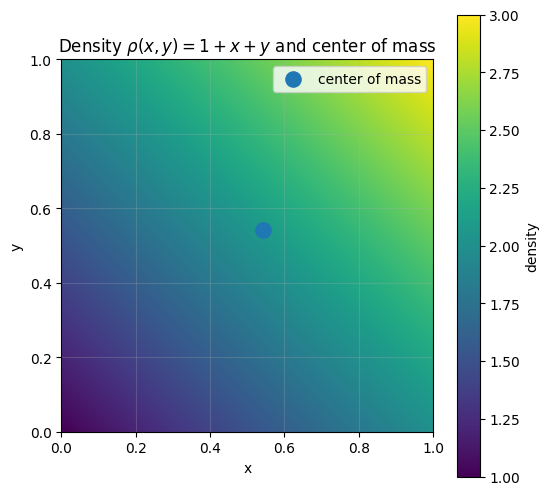

In [23]:
x, y, X, Y = make_grid(0, 1, 0, 1, n=300)
RHO = rho_square(X, Y)

plt.figure(figsize=(6, 6))
im = plt.imshow(RHO, extent=[0,1,0,1], origin="lower", aspect="equal")
plt.scatter([xbar], [ybar], s=120, label="center of mass")
plt.colorbar(im, label="density")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Density $\rho(x,y)=1+x+y$ and center of mass")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 16. Center of mass on a triangular region

Let

$$
R=\{(x,y):0\le y\le x,\;0\le x\le1\}
$$

with density

$$
\rho(x,y)=1+x.
$$

In [24]:
def triangle_mask(X, Y):
    return (0 <= X) & (X <= 1) & (0 <= Y) & (Y <= X)

def rho_triangle(X, Y):
    return 1 + X

m, *_ = midpoint_region(rho_triangle, 0, 1, 0, 1, triangle_mask, nx=700, ny=700)
My, *_ = midpoint_region(lambda X, Y: X*rho_triangle(X, Y), 0, 1, 0, 1, triangle_mask, nx=700, ny=700)
Mx, *_ = midpoint_region(lambda X, Y: Y*rho_triangle(X, Y), 0, 1, 0, 1, triangle_mask, nx=700, ny=700)

xbar = My/m
ybar = Mx/m

print("Mass:", m)
print("Center of mass:", (xbar, ybar))

Mass: 0.8344045918367347
Center of mass: (0.6998141571244874, 0.3502642214193864)


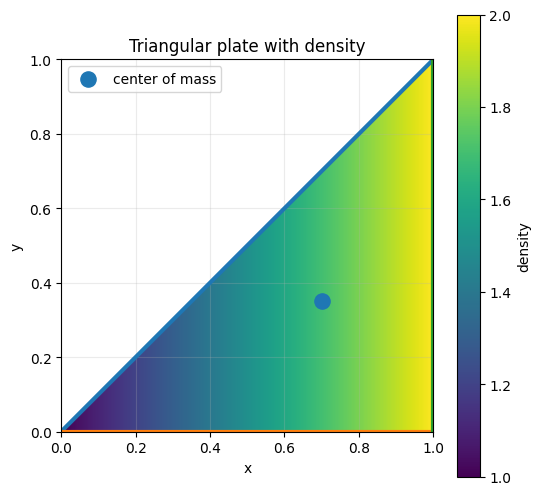

In [25]:
x, y, X, Y = make_grid(0, 1, 0, 1, n=350)
inside = triangle_mask(X, Y)
RHO = np.where(inside, rho_triangle(X, Y), np.nan)

plt.figure(figsize=(6, 6))
im = plt.imshow(RHO, extent=[0,1,0,1], origin="lower", aspect="equal")
plt.plot([0,1], [0,1], linewidth=3)
plt.plot([0,1], [0,0], linewidth=3)
plt.plot([1,1], [0,1], linewidth=3)
plt.scatter([xbar], [ybar], s=120, label="center of mass")
plt.colorbar(im, label="density")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Triangular plate with density")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part VIII. Probability interpretation

If $f(x,y)$ is a joint probability density, then

$$
P((X,Y)\in R)=\iint_R f(x,y)\,dA.
$$

Also,

$$
E[X]=\iint x f(x,y)\,dA,
\qquad
E[Y]=\iint y f(x,y)\,dA.
$$

## 17. Uniform distribution on a triangle

Let $(X,Y)$ be uniformly distributed on

$$
R=\{(x,y):0\le y\le x,\;0\le x\le1\}.
$$

The area is $1/2$, so the density is

$$
f(x,y)=2
$$

on the triangle.

In [26]:
area_triangle, *_ = midpoint_region(one_function, 0, 1, 0, 1, triangle_mask, nx=700, ny=700)

EX_integral, *_ = midpoint_region(lambda X, Y: 2*X, 0, 1, 0, 1, triangle_mask, nx=700, ny=700)
EY_integral, *_ = midpoint_region(lambda X, Y: 2*Y, 0, 1, 0, 1, triangle_mask, nx=700, ny=700)

print("Area of triangle:", area_triangle)
print("Integral of density 2 over triangle:", 2*area_triangle)
print("E[X]:", EX_integral)
print("E[Y]:", EY_integral)

# Exact: E[X]=2/3, E[Y]=1/3 for this triangle.
print("Exact E[X], E[Y]:", 2/3, 1/3)

Area of triangle: 0.5007142857142857
Integral of density 2 over triangle: 1.0014285714285713
E[X]: 0.667380612244898
E[Y]: 0.33404795918367347
Exact E[X], E[Y]: 0.6666666666666666 0.3333333333333333


## 18. Probability of a subregion

Compute

$$
P(Y\le 0.25)
$$

for the same uniform triangle.

In [27]:
def subregion_mask(X, Y):
    return triangle_mask(X, Y) & (Y <= 0.25)

prob_est, *_ = midpoint_region(lambda X, Y: 2*np.ones_like(X), 0, 1, 0, 1, subregion_mask, nx=700, ny=700)

print("Estimated probability P(Y <= 0.25):", prob_est)

# Exact:
# y from 0 to 1/4, x from y to 1, density 2
# 2 * integral_0^{1/4} (1-y) dy = 2*(1/4 - 1/32)=7/16
print("Exact probability:", 7/16)

Estimated probability P(Y <= 0.25): 0.43785714285714283
Exact probability: 0.4375


In [28]:
x, y, X, Y = make_grid(0, 1, 0, 1, n=350)
tri = triangle_mask(X, Y)
sub = subregion_mask(X, Y)

plt.figure(figsize=(6, 6))
plt.contourf(X, Y, tri.astype(float), levels=[-0.5, 0.5, 1.5], alpha=0.25)
plt.contourf(X, Y, sub.astype(float), levels=[0.5, 1.5], alpha=0.65)
plt.plot([0,1], [0,1], linewidth=3)
plt.plot([0,1], [0,0], linewidth=3)
plt.axhline(0.25, linestyle="--")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Subregion for $P(Y\le 0.25)$")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

ValueError: 
P(Y\le 0.25)
   ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 3), (line:1, col:4)

<Figure size 600x600 with 1 Axes>

---

# Part IX. Chapter mini-project: terrain volume and average height

A terrain height function $h(x,y)$ gives elevation above a region.  
The double integral

$$
\iint_R h(x,y)\,dA
$$

is the total volume under the terrain above $R$.

The average height is

$$
\frac{1}{\text{Area}(R)}\iint_R h(x,y)\,dA.
$$

## 19. Define a terrain function and a lake region

Let the lake region be the disk

$$
(x-0.3)^2+(y+0.2)^2\le 1.2^2.
$$

In [29]:
def terrain(X, Y):
    hill1 = 2.0*np.exp(-0.7*((X - 0.8)**2 + (Y + 0.4)**2))
    hill2 = 1.1*np.exp(-0.9*((X + 0.9)**2 + (Y - 0.8)**2))
    valley = -0.7*np.exp(-1.2*((X - 0.2)**2 + (Y - 0.9)**2))
    waves = 0.15*np.sin(3*X)*np.cos(2*Y)
    return hill1 + hill2 + valley + waves

def lake_mask(X, Y):
    return (X - 0.3)**2 + (Y + 0.2)**2 <= 1.2**2

xmin, xmax = -1.3, 1.9
ymin, ymax = -1.8, 1.4

area_lake, Xmid, Ymid, Zmid, inside, dx, dy = midpoint_region(
    one_function, xmin, xmax, ymin, ymax, lake_mask, nx=500, ny=500
)
volume_lake, *_ = midpoint_region(
    terrain, xmin, xmax, ymin, ymax, lake_mask, nx=500, ny=500
)
avg_height = volume_lake/area_lake

print("Lake area estimate:", area_lake)
print("Exact disk area:", np.pi*1.2**2)
print("Terrain volume over lake:", volume_lake)
print("Average terrain height over lake:", avg_height)

Lake area estimate: 4.52182016
Exact disk area: 4.523893421169302
Terrain volume over lake: 5.056447590908741
Average terrain height over lake: 1.1182327938731516


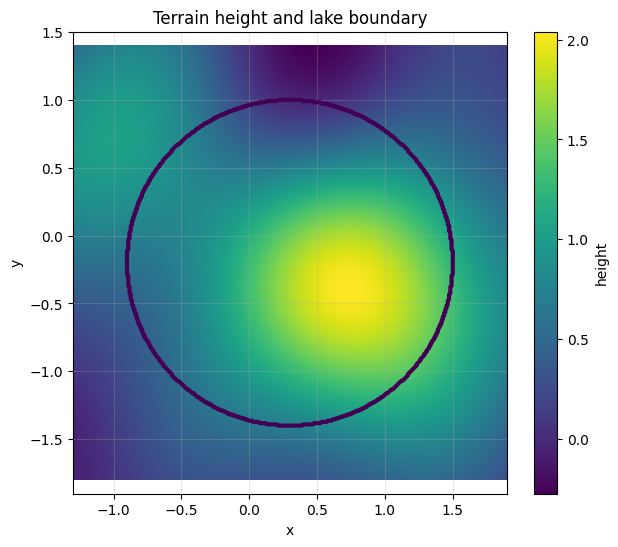

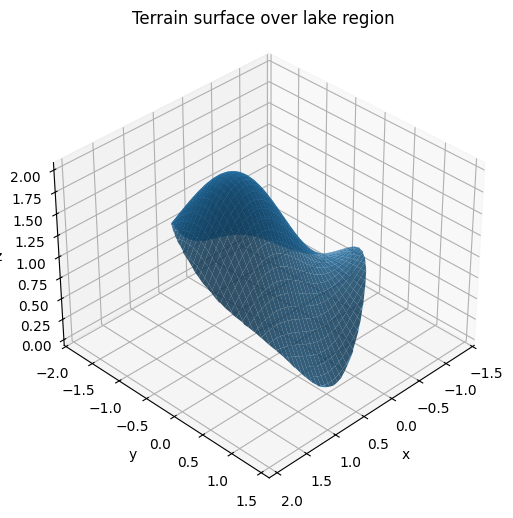

In [30]:
x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=350)
H = terrain(X, Y)
inside_grid = lake_mask(X, Y)

plt.figure(figsize=(7, 6))
im = plt.imshow(H, extent=[xmin,xmax,ymin,ymax], origin="lower", aspect="auto")
plt.contour(X, Y, inside_grid.astype(float), levels=[0.5], linewidths=3)
plt.colorbar(im, label="height")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain height and lake boundary")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

fig, ax = make_3d_axes(title="Terrain surface over lake region", elev=35, azim=45)
H_masked = np.where(inside_grid, H, np.nan)
ax.plot_surface(X, Y, H_masked, linewidth=0, alpha=0.85)
plt.show()

## 20. Compare grid and Monte Carlo estimates

In [31]:
for n in [5_000, 20_000, 80_000, 200_000]:
    est, se, *_ = monte_carlo_integral(
        terrain, xmin, xmax, ymin, ymax, mask=lake_mask, n=n, seed=202 + n
    )
    print(f"n={n:8d}, volume estimate={est:.8f}, std error={se:.8f}, grid reference diff={est-volume_lake:.8f}")

n=    5000, volume estimate=4.95048205, std error=0.09235816, grid reference diff=-0.10596555
n=   20000, volume estimate=5.05787383, std error=0.04648338, grid reference diff=0.00142624
n=   80000, volume estimate=5.03635659, std error=0.02313812, grid reference diff=-0.02009100
n=  200000, volume estimate=5.07955911, std error=0.01469308, grid reference diff=0.02311152


## 21. Mini-project questions

Answer the following in a markdown cell:

1. What does the double integral of terrain height over the lake represent?
2. Why is the average height equal to volume divided by area?
3. How does the Monte Carlo estimate change as sample size increases?
4. Which method is more accurate here: grid midpoint or Monte Carlo? Why?
5. How would the problem change if the region were irregular or defined by data?

In [32]:
print("Mini-project summary")
print("--------------------")
print("Area:", area_lake)
print("Volume:", volume_lake)
print("Average height:", avg_height)
print("Bounding box area:", (xmax-xmin)*(ymax-ymin))
print("Fraction of bounding box occupied by lake:", area_lake/((xmax-xmin)*(ymax-ymin)))

Mini-project summary
--------------------
Area: 4.52182016
Volume: 5.056447590908741
Average height: 1.1182327938731516
Bounding box area: 10.240000000000002
Fraction of bounding box occupied by lake: 0.4415839999999999


---

# Part X. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Midpoint Riemann sum

Approximate

$$
\iint_{[0,1]\times[0,2]}(x^2+y^2)\,dA
$$

using midpoint sums with $n\times n$ subrectangles for $n=4,8,16,32$.

Compare with the exact value.

In [33]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [34]:
def exercise_A_f(X, Y):
    return X**2 + Y**2

# Exact: integral_0^1 integral_0^2 (x^2+y^2) dy dx
# = integral_0^1 (2x^2 + 8/3) dx = 2/3 + 8/3 = 10/3.
exact_A = 10/3

for n in [4, 8, 16, 32, 64]:
    approx, *_ = midpoint_riemann_rectangle(exercise_A_f, 0, 1, 0, 2, nx=n, ny=n)
    print(f"n={n:3d}, approximation={approx:.10f}, error={approx-exact_A:.10f}")

n=  4, approximation=3.2812500000, error=-0.0520833333
n=  8, approximation=3.3203125000, error=-0.0130208333
n= 16, approximation=3.3300781250, error=-0.0032552083
n= 32, approximation=3.3325195312, error=-0.0008138021
n= 64, approximation=3.3331298828, error=-0.0002034505


## Exercise B. Area between curves

Compute the area of the region between

$$
y=x^2
$$

and

$$
y=x
$$

for $0\le x\le1$.

In [35]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [36]:
def mask_between_curves(X, Y):
    return (0 <= X) & (X <= 1) & (X**2 <= Y) & (Y <= X)

area_B, *_ = midpoint_region(one_function, 0, 1, 0, 1, mask_between_curves, nx=700, ny=700)
exact_B = 1/6

print("Area estimate:", area_B)
print("Exact area:", exact_B)

Area estimate: 0.1673387755102041
Exact area: 0.16666666666666666


## Exercise C. Change order of integration

Evaluate

$$
\int_0^1\int_y^1 (x+y)\,dx\,dy
$$

and identify the equivalent Type I region.

In [37]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [38]:
val_C, *_ = iterated_type2(
    lambda X, Y: X + Y,
    0, 1,
    lambda y: y,
    lambda y: 1 + 0*y,
    ny=600,
    nx=600
)

# Equivalent Type I: 0 <= x <= 1, 0 <= y <= x.
val_C_type1, *_ = iterated_type1(
    lambda X, Y: X + Y,
    0, 1,
    lambda x: 0*x,
    lambda x: x,
    nx=600,
    ny=600
)

print("Original order value:", val_C)
print("Changed Type I order value:", val_C_type1)
print("Exact value:", 1/2)

Original order value: 0.4999993032349408
Changed Type I order value: 0.5000006967650592
Exact value: 0.5


## Exercise D. Average value

Compute the average value of

$$
f(x,y)=x+y
$$

on the triangle

$$
0\le y\le x,\qquad 0\le x\le1.
$$

In [39]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [40]:
area_D, *_ = midpoint_region(one_function, 0, 1, 0, 1, triangle_mask, nx=700, ny=700)
integral_D, *_ = midpoint_region(lambda X, Y: X + Y, 0, 1, 0, 1, triangle_mask, nx=700, ny=700)
avg_D = integral_D/area_D

print("Area:", area_D)
print("Integral:", integral_D)
print("Average value:", avg_D)
print("Exact average value:", 1.0)

Area: 0.5007142857142857
Integral: 0.5007142857142857
Average value: 1.0
Exact average value: 1.0


## Exercise E. Monte Carlo integration

Use Monte Carlo integration to estimate

$$
\iint_{x^2+y^2\le1} e^{-x^2-y^2}\,dA.
$$

Compare with a midpoint-grid estimate.

In [41]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

In [42]:
grid_E, *_ = midpoint_region(f_gaussian, -1, 1, -1, 1, disk_mask, nx=800, ny=800)
mc_E, se_E, *_ = monte_carlo_integral(f_gaussian, -1, 1, -1, 1, mask=disk_mask, n=300_000, seed=1300)

print("Grid midpoint estimate:", grid_E)
print("Monte Carlo estimate:", mc_E)
print("Monte Carlo standard error:", se_E)

# Exact by polar coordinates: 2π∫_0^1 e^{-r^2}r dr = π(1-e^{-1})
print("Exact value:", np.pi*(1-np.exp(-1)))

Grid midpoint estimate: 1.9858588627918898
Monte Carlo estimate: 1.987612853269216
Monte Carlo standard error: 0.002228228223620658
Exact value: 1.9858653037988714


---

# Formula summary

## Double integral as limit of Riemann sums

$$
\iint_R f(x,y)\,dA
=
\lim_{\|\Delta\|\to0}
\sum_{i,j} f(x_{ij}^*,y_{ij}^*)\,\Delta A.
$$

## Rectangle

$$
\iint_{[a,b]\times[c,d]} f(x,y)\,dA
=
\int_a^b\int_c^d f(x,y)\,dy\,dx.
$$

## Fubini's theorem

For continuous $f$ on a rectangle,

$$
\int_a^b\int_c^d f(x,y)\,dy\,dx
=
\int_c^d\int_a^b f(x,y)\,dx\,dy.
$$

## Type I region

$$
R=\{(x,y):a\le x\le b,\;g_1(x)\le y\le g_2(x)\}.
$$

Then

$$
\iint_R f\,dA
=
\int_a^b\int_{g_1(x)}^{g_2(x)} f(x,y)\,dy\,dx.
$$

## Type II region

$$
R=\{(x,y):c\le y\le d,\;h_1(y)\le x\le h_2(y)\}.
$$

Then

$$
\iint_R f\,dA
=
\int_c^d\int_{h_1(y)}^{h_2(y)} f(x,y)\,dx\,dy.
$$

## Area

$$
\text{Area}(R)=\iint_R1\,dA.
$$

## Average value

$$
f_{\text{avg}}
=
\frac{1}{\text{Area}(R)}\iint_R f(x,y)\,dA.
$$

## Mass and center of mass

$$
m=\iint_R\rho\,dA,
$$

$$
\bar x=\frac1m\iint_R x\rho\,dA,
\qquad
\bar y=\frac1m\iint_R y\rho\,dA.
$$

## Monte Carlo integration

If $B$ is a bounding box,

$$
\iint_R f\,dA
=
\operatorname{Area}(B)\,
\mathbb E[f(X,Y)\mathbf 1_R(X,Y)].
$$

# End of Chapter 13 Lab

You have used Python to explore:

- double integrals as Riemann sums,
- midpoint approximations,
- convergence of numerical integration,
- Fubini's theorem,
- Type I and Type II regions,
- changing the order of integration,
- area and average value,
- mass and center of mass,
- probability interpretation,
- Monte Carlo integration,
- and a terrain-volume mini-project.

These ideas prepare for double integrals in polar coordinates, triple integrals, change of variables, vector fields, flux, and applications in probability and physics.